### Imports

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud

DATA_DIR = "data"
META_PATH = os.path.join(DATA_DIR, "metadata.csv")
VOCAB_PATH = os.path.join(DATA_DIR, "vocab.txt")
TOK_DIR = os.path.join(DATA_DIR, "tokenized")

### Load Data

In [2]:
df = pd.read_csv(META_PATH)

with open(VOCAB_PATH, "r", encoding="utf-8") as f:
    vocab = [line.strip() for line in f if line.strip()]
tok2id = {t:i for i,t in enumerate(vocab)}

PAD = tok2id.get("<pad>", None)
UNK = tok2id.get("<unk>", None)
BOS = tok2id.get("<bos>", None)
EOS = tok2id.get("<eos>", None)
NUM = tok2id.get("<num>", None)

special_ids = {i for i in [PAD, UNK, BOS, EOS, NUM] if i is not None}
print("vocab size:", len(vocab))
print("special:", {"<pad>": PAD, "<unk>": UNK, "<bos>": BOS, "<eos>": EOS, "<num>": NUM})

PUNCT = {",",".","!","?",";",":","-","(",")","[","]",'"',"'"}
punct_ids = {tok2id[t] for t in PUNCT if t in tok2id}

def load_ids_file(path: str):
    with open(path, "r", encoding="utf-8") as f:
        s = f.read().strip()
    return np.fromstring(s, sep=" ", dtype=np.int32) if s else np.array([], dtype=np.int32)

vocab size: 30000
special: {'<pad>': 0, '<unk>': 1, '<bos>': 2, '<eos>': 3, '<num>': 4}


## Docs

In [3]:
display(df.head())

print("Documents:", len(df))

,ebook_id,title,author,language,book_page_url,txt_url,txt_path,sha256,byte_len,char_len,word_count,downloaded_at_utc,cleaned_at_utc,clean_word_count,norm_word_count,token_count,unk_count,unk_rate
0,11,Alice's Adventures in Wonderland,Lewis Carroll,English,https://www.gutenberg.org/ebooks/11,https://www.gutenberg.org/ebooks/11.txt.utf-8,data\texts_cleaned\11.txt,adb142ab3a822bcfdc30efd2f753ecdafb099838cae336...,151069,144574,27441,2026-03-18T21:44:15+00:00,2026-03-18T21:56:48+00:00,27314,26655,34000,78,0.002294
1,12,Through the Looking-Glass,Lewis Carroll,English,https://www.gutenberg.org/ebooks/12,https://www.gutenberg.org/ebooks/12.txt.utf-8,data\texts_cleaned\12.txt,a679a5ea1929967ecdfab3688e3c3ffd409f7cda51d57f...,172645,164216,31127,2026-03-18T21:44:18+00:00,2026-03-18T21:56:48+00:00,30643,29702,38142,191,0.005008
2,16,Peter Pan : [Peter and Wendy],J. M. Barrie,English,https://www.gutenberg.org/ebooks/16,https://www.gutenberg.org/ebooks/16.txt.utf-8,data\texts_cleaned\16.txt,ee56ad5d1ab57c1d430ae23af21e7bf37a42b45ebe8a7a...,262712,255550,48051,2026-03-18T21:44:22+00:00,2026-03-18T21:56:48+00:00,47739,47213,58127,409,0.007036
3,41,The Legend of Sleepy Hollow,Washington Irving,English,https://www.gutenberg.org/ebooks/41,https://www.gutenberg.org/ebooks/41.txt.utf-8,data\texts_cleaned\41.txt,56be68b887ed255ab21c6e75a2cc242f7ac521e8a3f65c...,69925,69756,12375,2026-03-18T21:44:25+00:00,2026-03-18T21:56:48+00:00,12375,12343,14147,221,0.015622
4,45,Anne of Green Gables,L. M. Montgomery,English,https://www.gutenberg.org/ebooks/45,https://www.gutenberg.org/ebooks/45.txt.utf-8,data\texts_cleaned\45.txt,30c3f990c4ac260fe95a40bbc8464c2326ea0665d715af...,576043,561066,107151,2026-03-18T21:44:28+00:00,2026-03-18T21:56:48+00:00,105666,102094,120863,1063,0.008795


Documents: 170


### Duplicates

In [4]:
dup_groups = df.groupby("sha256").size().sort_values(ascending=False)
print("exact duplicate groups (count>1):", (dup_groups > 1).sum())

exact duplicate groups (count>1): 0


### Tokens

In [5]:
def safe_sum(col):
    return df[col].fillna(0).astype(int).sum() if col in df.columns else None

total_tokens = safe_sum("token_count")
total_unk = safe_sum("unk_count")

print("Total tokens:", f"{total_tokens:,}" if total_tokens is not None else "n/a")
print("Total UNK:", f"{total_unk:,}" if total_unk is not None else "n/a")
if total_tokens and total_unk is not None:
    print("UNK rate:", f"{100*total_unk/total_tokens:.3f}%")

if "token_count" in df.columns:
    print("Avg tokens / doc:", f"{df['token_count'].mean():,.0f}")
    print("Median tokens / doc:", f"{df['token_count'].median():,.0f}")
    print("Min tokens / doc:", f"{df['token_count'].min():,}")
    print("Max tokens / doc:", f"{df['token_count'].max():,}")

Total tokens: 15,875,695
Total UNK: 186,731
UNK rate: 1.176%
Avg tokens / doc: 93,386
Median tokens / doc: 90,528
Min tokens / doc: 2,642
Max tokens / doc: 463,918


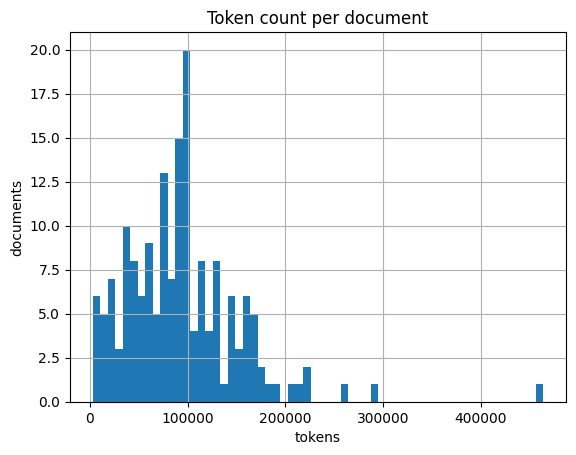

In [6]:
plt.figure()
df["token_count"].hist(bins=60)
plt.title("Token count per document")
plt.xlabel("tokens")
plt.ylabel("documents")
plt.show()

Long tail (Right skewed) -> applying log transformation 

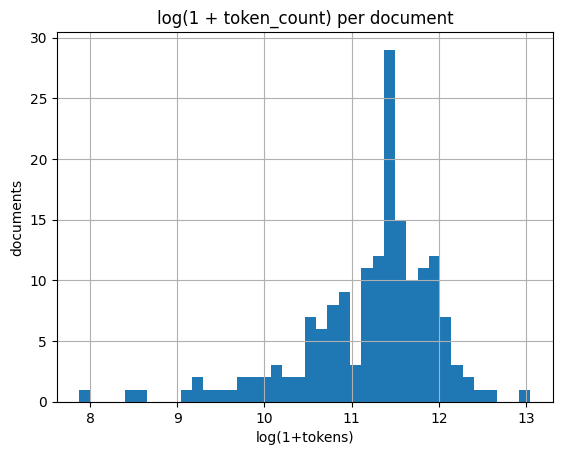

In [7]:
plt.figure()
np.log1p(df["token_count"]).hist(bins=40)
plt.title("log(1 + token_count) per document")
plt.xlabel("log(1+tokens)")
plt.ylabel("documents")
plt.show()

### Vocab

In [8]:
tok2id = {t:i for i,t in enumerate(vocab)}
print("Vocab size:", len(vocab))
print("Special IDs:", {t: tok2id.get(t) for t in ["<pad>", "<unk>", "<bos>", "<eos>", "<num>"]})

Vocab size: 30000
Special IDs: {'<pad>': 0, '<unk>': 1, '<bos>': 2, '<eos>': 3, '<num>': 4}


Most frequent tokens

In [9]:
freq = Counter()
scanned = 0
for eid in df["ebook_id"].astype(str):
    p = os.path.join(TOK_DIR, f"{eid}.ids.txt")
    if not os.path.exists(p): 
        continue
    ids = load_ids_file(p)
    if ids.size == 0:
        continue
    freq.update(ids.tolist())
    scanned += 1

print("scanned:", scanned, "docs")
print("counted tokens:", f"{sum(freq.values()):,}")

scanned: 170 docs
counted tokens: 15,875,695


In [10]:
special = {tok2id.get(t) for t in ["<pad>", "<unk>", "<bos>", "<eos>", "<num>"] if tok2id.get(t) is not None}

top = [(i,c) for i,c in freq.most_common(50) if i not in special]
top_tokens = [(vocab[i], c) for i,c in top[:30]]

pd.DataFrame(top_tokens, columns=["token", "count"])

,token,count
0,",",1008900
1,the,913313
2,.,674201
3,and,485687
4,of,383753
5,"""",358627
6,to,341228
7,a,286423
8,in,211131
9,-,193660


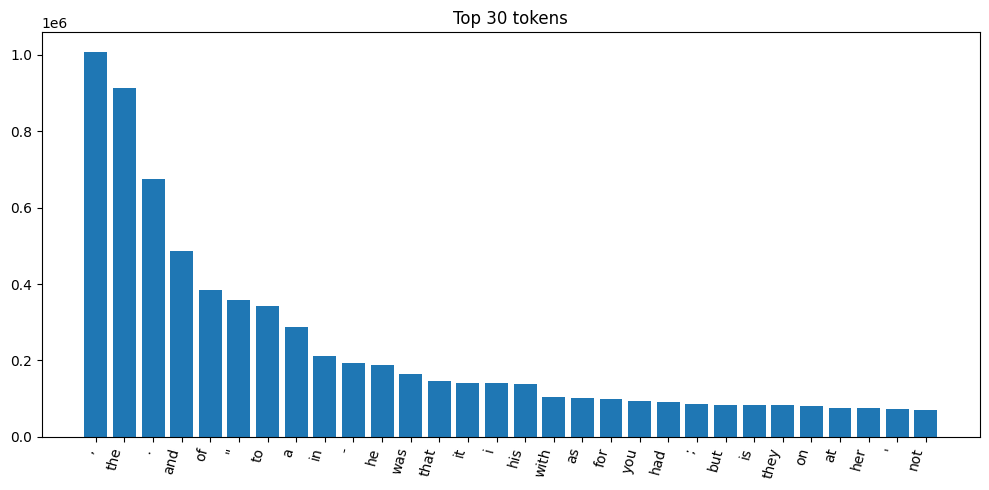

In [11]:
labels = [t for t,_ in top_tokens]
counts = [c for _,c in top_tokens]

plt.figure(figsize=(10,5))
plt.bar(range(len(labels)), counts)
plt.xticks(range(len(labels)), labels, rotation=75, ha="right")
plt.title(f"Top 30 tokens")
plt.tight_layout()
plt.show()

top-  100 coverage: 59.92%
top- 1000 coverage: 80.88%
top- 5000 coverage: 92.77%
top-10000 coverage: 96.48%
top-20000 coverage: 99.05%


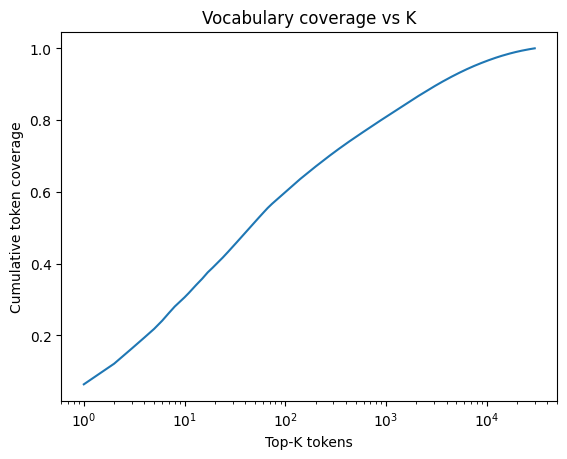

In [12]:
counts = np.array([c for _,c in freq.most_common()], dtype=np.int64)
total = counts.sum()
cum = np.cumsum(counts) / total

# compute coverage at a few K
for k in [100, 1000, 5000, 10000, 20000, 30000]:
    if k <= len(cum):
        print(f"top-{k:>5} coverage: {100*cum[k-1]:.2f}%")

plt.figure()
plt.plot(np.arange(1, len(cum)+1), cum)
plt.xscale("log")
plt.title("Vocabulary coverage vs K")
plt.xlabel("Top-K tokens")
plt.ylabel("Cumulative token coverage")
plt.show()

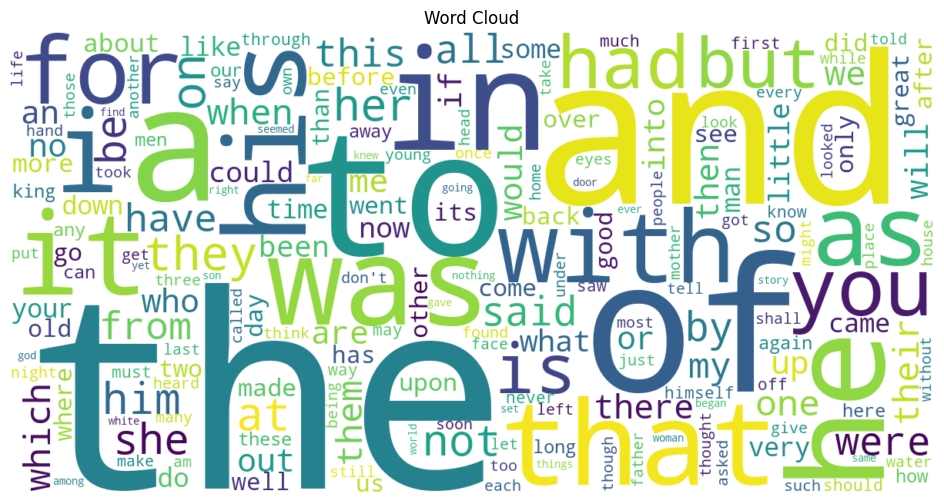

In [13]:
stop_tokens = set(["<pad>", "<unk>", "<bos>", "<eos>", "<num>"])
punct_like = set([",", ".", "!", "?", ";", ":", "-", "(", ")", "[", "]", '"', "'"])

freq_words = {}
for idx, c in freq.items():
    tok = vocab[idx] if 0 <= idx < len(vocab) else None
    if tok is None:
        continue
    if tok in stop_tokens:
        continue
    if tok in punct_like:
        continue
    freq_words[tok] = int(c)

wc = WordCloud(width=1200, height=600, background_color="white", max_words=200)
img = wc.generate_from_frequencies(freq_words)

plt.figure(figsize=(12,6))
plt.imshow(img, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()

### OOV analysis

,ebook_id,title,author,token_count,unk_count,unk_rate
30,2306,"Uncle Remus, His Songs and His Sayings",Joel Chandler Harris,70363,3194,0.045393
64,11029,American Hero-Myths: A Study in the Native Rel...,Daniel G. Brinton,81214,3640,0.044820
71,13008,"The Edda, Volume 2",Lucy Winifred Faraday,16813,631,0.037530
70,13007,"The Edda, Volume 1",Lucy Winifred Faraday,14708,542,0.036851
99,19347,The Myths of the New World,Daniel G. Brinton,111929,3661,0.032708
...,...,...,...,...,...,...
0,11,Alice's Adventures in Wonderland,Lewis Carroll,34000,78,0.002294
97,19033,Alice's Adventures in Wonderland,Lewis Carroll,12065,27,0.002238
111,20748,Favorite Fairy Tales,NaN,47616,93,0.001953
129,23462,More Russian Picture Tales,Valerian Viliamovich Karrik,8731,14,0.001603


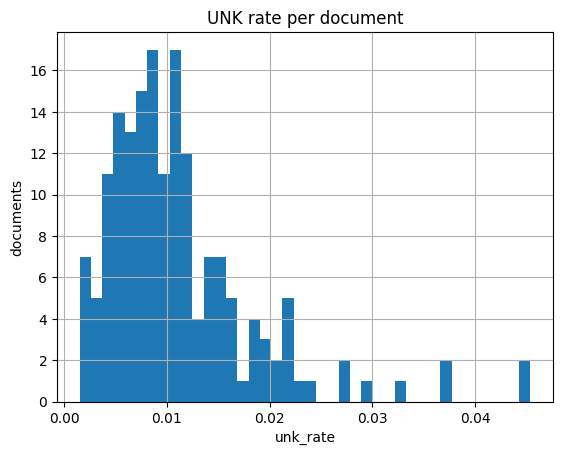

In [14]:
df["unk_rate"] = df["unk_count"].fillna(0) / df["token_count"].replace(0, np.nan)
display(df.sort_values("unk_rate", ascending=False)[
    ["ebook_id", "title", "author", "token_count", "unk_count", "unk_rate"]
])

plt.figure()
df["unk_rate"].fillna(0).hist(bins=40)
plt.title("UNK rate per document")
plt.xlabel("unk_rate")
plt.ylabel("documents")
plt.show()

In [15]:
WORD_RE = r"[a-z]+(?:'[a-z]+)?"
PUNCT_RE = r"[.,!?;:\-—()\[\]\"']"
TOKEN_RE = re.compile(rf"{WORD_RE}|{PUNCT_RE}|<num>", re.IGNORECASE)
DIGIT_RE = re.compile(r"\d+")
WHITESPACE_RE = re.compile(r"\s+")
CHAR_MAP = str.maketrans({
    "“": '"', "”": '"', "„": '"',
    "’": "'", "‘": "'",
    "—": "-", "–": "-",
    "…": "...",
})

vocab_set = set(vocab)

def normalize_text(text: str) -> str:
    text = text.replace("\r\n","\n").replace("\r","\n")
    text = text.translate(CHAR_MAP).lower()
    text = DIGIT_RE.sub(" <num> ", text)
    text = WHITESPACE_RE.sub(" ", text).strip()
    return text

oov = Counter()
oov_total = 0
tok_total = 0

for _, r in df.iterrows():
    path = r.get("txt_path", "")
    if not path or not os.path.exists(path): 
        continue
    with open(path, "r", encoding="utf-8") as f:
        raw = f.read()

    norm = normalize_text(raw)
    toks = TOKEN_RE.findall(norm)
    tok_total += len(toks)

    for t in toks:
        if t not in vocab_set:
            oov[t] += 1
            oov_total += 1

print("total raw tokens scanned:", f"{tok_total:,}")
print("OOV tokens:", f"{oov_total:,}", f"({100*oov_total/max(1,tok_total):.3f}%)")
pd.DataFrame(oov.most_common(50), columns=["oov_token","count"])

total raw tokens scanned: 15,875,355
OOV tokens: 186,731 (1.176%)


,oov_token,count
0,uncorked,10
1,punching,10
2,pennyworth,10
3,scrawled,10
4,rollicking,10
5,spinsters,10
6,pirate's,10
7,noodles,10
8,smirked,10
9,tags,10


### Non-ascii outliers

,ebook_id,title,non_ascii_frac,non_ascii_per_letter
1,12,Through the Looking-Glass,0.025954,0.034968
42,5348,"Ragged Dick, Or, Street Life in New York with ...",0.022886,0.030303
0,11,Alice's Adventures in Wonderland,0.022556,0.030167
23,837,The Story of the Amulet,0.020937,0.027586
8,113,The Secret Garden,0.020358,0.026686
22,836,The Phoenix and the Carpet,0.017895,0.023586
6,51,Anne of the Island,0.017757,0.023119
18,659,"Paul the Peddler; Or, The Fortunes of a Young ...",0.016885,0.022465
31,2781,Just so stories,0.014526,0.019306
2,16,Peter Pan : [Peter and Wendy],0.014086,0.018465


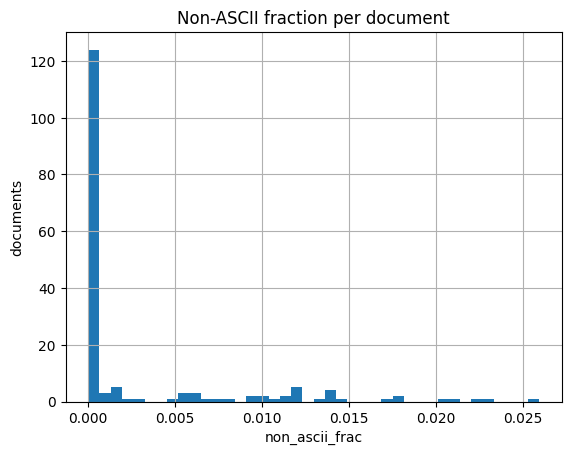

In [16]:
def doc_char_stats(path):
    with open(path, "r", encoding="utf-8") as f:
        txt = f.read()
    if not txt:
        return 0.0, 0.0
    n = len(txt)
    non_ascii = sum(1 for ch in txt if ord(ch) > 127)
    letters = sum(1 for ch in txt if ch.isalpha())
    return non_ascii/n, (non_ascii/max(1,letters))

stats = []
for _, r in df.iterrows():
    p = r.get("txt_path","")
    if not p or not os.path.exists(p): 
        continue
    non_ascii_frac, non_ascii_per_letter = doc_char_stats(p)
    stats.append((r["ebook_id"], r.get("title",""), non_ascii_frac, non_ascii_per_letter))

lang_df = pd.DataFrame(stats, columns=["ebook_id","title","non_ascii_frac","non_ascii_per_letter"])
display(lang_df.sort_values("non_ascii_frac", ascending=False).head(10))

plt.figure()
lang_df["non_ascii_frac"].hist(bins=40)
plt.title("Non-ASCII fraction per document")
plt.xlabel("non_ascii_frac")
plt.ylabel("documents")
plt.show()

### Token type proportions

,token_count,unk_rate,num_rate,punct_rate
count,170.000000,170.000000,170.000000,170.000000
mean,93386.441176,0.011157,0.003213,0.166664
std,59373.206306,0.007480,0.006580,0.023382
min,2642.000000,0.001514,0.000000,0.090876
25%,52217.750000,0.006232,0.000148,0.152173
50%,90527.500000,0.009321,0.000664,0.166246
75%,120356.750000,0.014132,0.002755,0.178222
max,463918.000000,0.045393,0.042931,0.234631


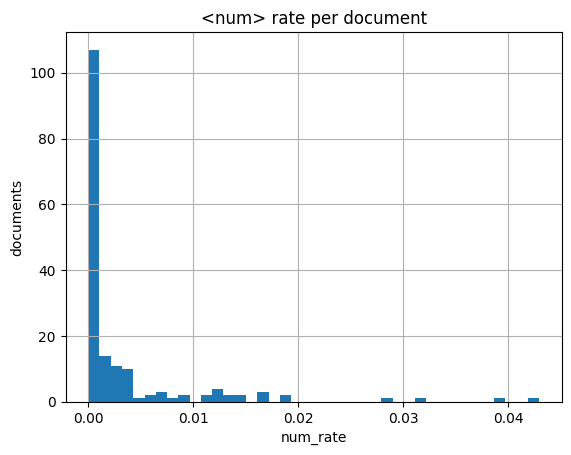

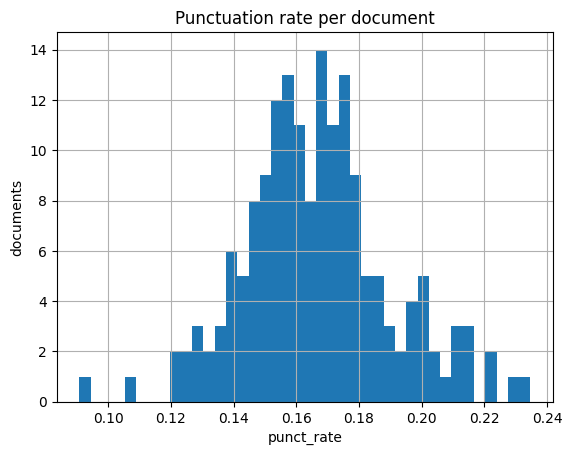

In [17]:
type_rows = []
for _, r in df.iterrows():
    eid = str(r["ebook_id"])
    p = os.path.join(TOK_DIR, f"{eid}.ids.txt")
    if not os.path.exists(p): 
        continue
    ids = load_ids_file(p)
    if ids.size == 0:
        continue

    n = ids.size
    unk = int((ids == UNK).sum()) if UNK is not None else 0
    num = int((ids == NUM).sum()) if NUM is not None else 0
    punct = int(np.isin(ids, list(punct_ids)).sum())

    type_rows.append((eid, n, unk/n, num/n, punct/n))

types = pd.DataFrame(type_rows, columns=["ebook_id","token_count","unk_rate","num_rate","punct_rate"])
display(types.describe())

plt.figure()
types["num_rate"].hist(bins=40)
plt.title("<num> rate per document")
plt.xlabel("num_rate")
plt.ylabel("documents")
plt.show()

plt.figure()
types["punct_rate"].hist(bins=40)
plt.title("Punctuation rate per document")
plt.xlabel("punct_rate")
plt.ylabel("documents")
plt.show()

### Sentence & paragraph length

In [18]:
def sentence_paragraph_stats(path):
    with open(path, "r", encoding="utf-8") as f:
        txt = f.read().lower()
    txt = re.sub(r"\s+", " ", txt).strip()

    sents = re.split(r"[.!?]+", txt)
    sent_lens = [len(re.findall(r"[a-z]+(?:'[a-z]+)?", s)) for s in sents if s.strip()]

    with open(path, "r", encoding="utf-8") as f:
        raw = f.read()
    paras = re.split(r"\n\s*\n", raw)
    para_lens = [len(re.findall(r"[a-z]+(?:'[a-z]+)?", p.lower())) for p in paras if p.strip()]

    return sent_lens, para_lens

all_sent = []
all_para = []
for _, r in df.iterrows():
    p = r.get("txt_path","")
    if not p or not os.path.exists(p): 
        continue
    sl, pl = sentence_paragraph_stats(p)
    all_sent.extend(sl)
    all_para.extend(pl)

sentences sampled: 761419 
paragraphs sampled: 269408
sentence len mean/median: 17.411531627133023 / 14.0
paragraph len mean/median: 49.20964113909015 / 30.0


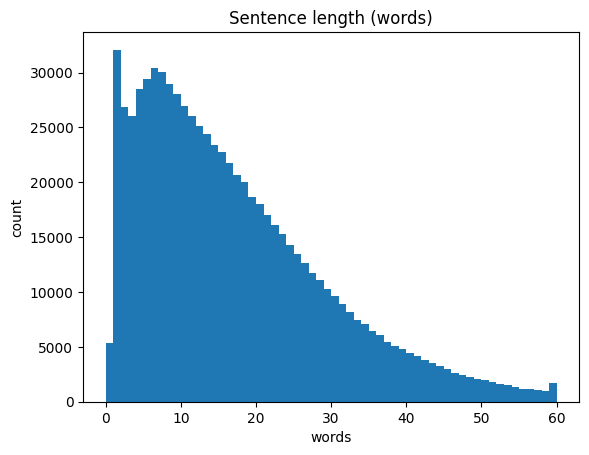

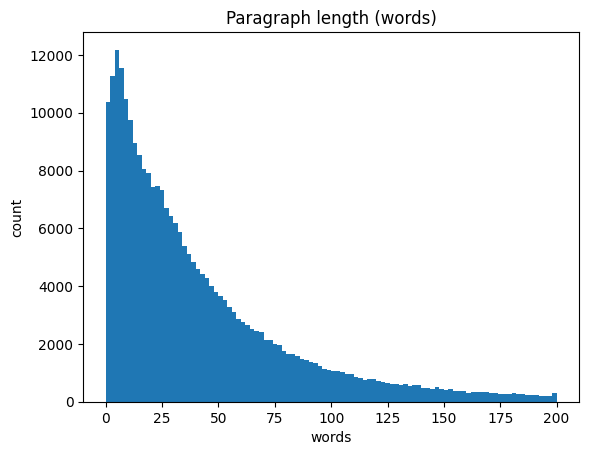

In [19]:

print("sentences sampled:", len(all_sent), "\nparagraphs sampled:", len(all_para))
print("sentence len mean/median:", np.mean(all_sent), "/", np.median(all_sent))
print("paragraph len mean/median:", np.mean(all_para), "/", np.median(all_para))

plt.figure()
plt.hist(all_sent, bins=60, range=(0,60))
plt.title("Sentence length (words)")
plt.xlabel("words")
plt.ylabel("count")
plt.show()

plt.figure()
plt.hist(all_para, bins=100, range=(0,200))
plt.title("Paragraph length (words)")
plt.xlabel("words")
plt.ylabel("count")
plt.show()

### Bigrams / trigrams

In [20]:
TOP_TOKENS_FOR_NGRAMS = 5000
top_ids = [i for i,_ in freq.most_common() if (i not in special_ids and i not in punct_ids)][:TOP_TOKENS_FOR_NGRAMS]
top_set = set(top_ids)

big = Counter()
tri = Counter()

for eid in df["ebook_id"].astype(str):
    p = os.path.join(TOK_DIR, f"{eid}.ids.txt")
    if not os.path.exists(p): 
        continue
    ids = load_ids_file(p).astype(np.int32)
    if ids.size < 3:
        continue

    # filter by top_set quickly
    mask = np.isin(ids, list(top_set))
    ids2 = ids[mask]
    if ids2.size < 3:
        continue

    # bigrams
    for a,b in zip(ids2[:-1], ids2[1:]):
        big[(int(a),int(b))] += 1
    # trigrams
    for a,b,c in zip(ids2[:-2], ids2[1:-1], ids2[2:]):
        tri[(int(a),int(b),int(c))] += 1

def decode_ngram(ng):
    if len(ng)==2:
        return f"{vocab[ng[0]]} {vocab[ng[1]]}"
    return f"{vocab[ng[0]]} {vocab[ng[1]]} {vocab[ng[2]]}"

top_bi = [(decode_ngram(k), v) for k,v in big.most_common(25)]
top_tr = [(decode_ngram(k), v) for k,v in tri.most_common(25)]

display(pd.DataFrame(top_bi, columns=["bigram","count"]))
display(pd.DataFrame(top_tr, columns=["trigram","count"]))

,bigram,count
0,of the,117486
1,in the,65120
2,to the,53417
3,and the,44245
4,the of,31609
5,on the,29512
6,it was,24278
7,at the,21552
8,to be,20520
9,from the,19434


,trigram,count
0,the of the,11816
1,one of the,5226
2,out of the,4304
3,there was a,3171
4,the and the,2982
5,of the and,2852
6,it was a,2781
7,as soon as,2558
8,of the of,2421
9,in the of,2213
